In [111]:
import numpy as np 
import pandas as pd

In [112]:
import seaborn as sb
import matplotlib.pyplot as plt

In [113]:
df = pd.read_csv("datasets\minute maid_from_dump.csv")
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",NaN,NaN,NaN,c,4.0,NaN,"Carbonated water, grape and apple juices from ...",NaN,NaN
1,0025000047244,Fruit Cooler Lemonade,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",france,NaN,NaN,NaN,e,NaN,NaN,NaN,NaN,NaN
2,0025000056017,100% Apple Juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",united-states,NaN,NaN,NaN,unknown,NaN,c,NaN,NaN,NaN
3,0025000056031,100% Orange Juice,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",united-states,NaN,NaN,California,e,1.0,a,"pure filtered water, concentrated orange juice...",10.0,48.9
4,0025000058073,Lemonade,Minute Maid,"beverages-and-beverages-preparations, beverage...",france,NaN,NaN,NaN,e,4.0,NaN,"Pure filtered water, high fructose corn syrup,...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,01070965,Minute maid,NaN,NaN,france,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
681,6975682483042,MZY Peach Juice Drink,"Minute Maid, Coca-Cola, MZY","beverages-and-beverages-preparations, plant-ba...","china, united-kingdom",NaN,NaN,NaN,e,4.0,NaN,"Water, fructose syrup, sugar, concentrated pea...",NaN,NaN
682,9416216001433,Minute Maid Pulpy,Orange,NaN,fiji,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
683,4902102060646,Apple 100%,Minute Maid,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


In [114]:
df.columns

Index(['code', 'product_name', 'brands', 'categories_tags', 'countries_tags',
       'packaging_tags', 'stores', 'purchase_places', 'nutriscore_grade',
       'nova_group', 'ecoscore_grade', 'ingredients_text',
       'nutriments.sugars_100g', 'nutriments.energy-kcal_100g'],
      dtype='object')

In [115]:
df.dtypes

code                            object
product_name                    object
brands                          object
categories_tags                 object
countries_tags                  object
packaging_tags                  object
stores                          object
purchase_places                 object
nutriscore_grade                object
nova_group                     float64
ecoscore_grade                  object
ingredients_text                object
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [116]:
df.code[df.duplicated()]

Series([], Name: code, dtype: object)

In [117]:
df.isnull().sum()

code                             0
product_name                    10
brands                          51
categories_tags                256
countries_tags                   0
packaging_tags                 618
stores                         659
purchase_places                646
nutriscore_grade                 0
nova_group                     498
ecoscore_grade                 542
ingredients_text               294
nutriments.sugars_100g         344
nutriments.energy-kcal_100g    341
dtype: int64

In [118]:
df.product_name = df.product_name.fillna('unknown')
df.brands = df.brands.fillna('unknown')
df.categories_tags = df.categories_tags.fillna('unknown')
df.packaging_tags = df.packaging_tags.fillna('unknown')
df.stores = df.stores.fillna('unknown')
df.purchase_places = df.purchase_places.fillna('unknown')
df.ecoscore_grade = df.ecoscore_grade.fillna('unknown')
df.ingredients_text = df.ingredients_text.fillna('unknown')


In [119]:
df.isnull().sum()

code                             0
product_name                     0
brands                           0
categories_tags                  0
countries_tags                   0
packaging_tags                   0
stores                           0
purchase_places                  0
nutriscore_grade                 0
nova_group                     498
ecoscore_grade                   0
ingredients_text                 0
nutriments.sugars_100g         344
nutriments.energy-kcal_100g    341
dtype: int64

# Extracting Countries


In [120]:
df.countries_tags.unique()

array(['france, united-states', 'france', 'united-states',
       'saint-pierre-and-miquelon', 'canada, france', 'canada',
       'france, martinique, switzerland', 'belgium, france, luxembourg',
       'taiwan', 'hong-kong', 'belgium, france', 'belgium',
       'belgium, france, martinique, switzerland', 'france, spain',
       'belgium, france, world', 'united-kingdom', 'spain', 'thailand',
       'india', 'france, luxembourg', 'belgium, france, germany',
       'belgium, france, switzerland', 'belgium, france, reunion',
       'france, spain, united-states', 'canada, switzerland',
       'martinique', 'switzerland', 'france, world', 'germany',
       'belgium, world', 'singapore', 'france, united-states, world',
       'senegal', 'united-states, world', 'mexico', 'canada, germany',
       'ireland', 'aruba', 'puerto-rico', 'luxembourg', 'kenya',
       'jamaica', 'philippines', 'barbados', 'ethiopia', 'suriname',
       'malaysia', 'mayotte', 'trinidad-and-tobago', 'norway', 'japan'

In [121]:
df.countries_tags.value_counts

<bound method IndexOpsMixin.value_counts of 0      france, united-states
1                     france
2              united-states
3              united-states
4                     france
               ...          
680                   france
681    china, united-kingdom
682                     fiji
683            united-states
684                    japan
Name: countries_tags, Length: 685, dtype: object>

In [122]:
raw_countries = df.countries_tags.str.split(',')
raw_countries

0      [france,  united-states]
1                      [france]
2               [united-states]
3               [united-states]
4                      [france]
                 ...           
680                    [france]
681    [china,  united-kingdom]
682                      [fiji]
683             [united-states]
684                     [japan]
Name: countries_tags, Length: 685, dtype: object

In [123]:
exploded_countries = raw_countries.explode()
exploded_countries

0               france
0        united-states
1               france
2        united-states
3        united-states
            ...       
681              china
681     united-kingdom
682               fiji
683      united-states
684              japan
Name: countries_tags, Length: 757, dtype: object

In [124]:
exploded_countries = exploded_countries.str.strip()
exploded_countries

0              france
0       united-states
1              france
2       united-states
3       united-states
            ...      
681             china
681    united-kingdom
682              fiji
683     united-states
684             japan
Name: countries_tags, Length: 757, dtype: object

In [125]:
exploded_countries.value_counts()

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
world                                   16
philippines                             16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
thailand                                 7
japan                                    7
luxembourg                               5
switzerland                              5
martinique                               4
netherlands                              4
singapore                                4
hong-kong                                3
united-kingdom                           3
malaysia                                 2
china                                    2
kenya                                    2
saint-pierre-and-miquelon              

In [126]:
exploded_countries.value_counts().sum()

np.int64(757)

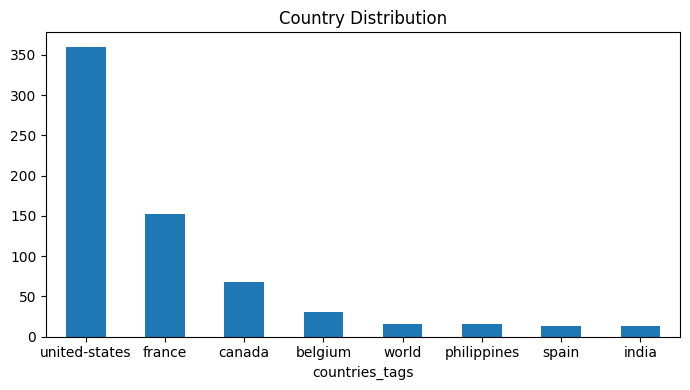

In [168]:
plt.figure(figsize=(7,4))

exploded_countries.value_counts().head(8).plot(kind='bar')

plt.title("Country Distribution")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

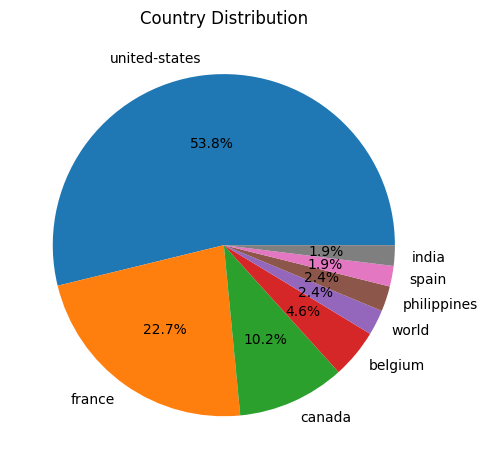

In [167]:
plt.figure(figsize=(5,5))

exploded_countries.value_counts().head(8).plot(kind='pie',autopct='%1.1f%%')

plt.title("Country Distribution")
plt.ylabel('')
plt.tight_layout()
plt.show()

##  Country Distribution – Key Insights

1. **United States dominates the dataset**, accounting for **53.8%** of all records. This indicates a strong representation of the U.S. market in the Minute Maid dataset.

2. **France is the second-largest contributor** with **22.7%**, followed by **Canada with 10.2%**. Together, the United States, France, and Canada account for approximately **86.7%** of the total records.

3. The remaining countries have relatively smaller shares: **Belgium (4.6%)**, **World (2.4%)**, **Philippines (2.4%)**, **Spain (1.9%)**, and **India (1.9%)**. This indicates that these markets have comparatively limited representation in the dataset.

###  Key Takeaway

The remaining countries have limited data representation, making it difficult to derive statistically meaningful insights or perform further reliable analysis. Therefore, the analysis primarily focuses on countries with sufficient data coverage.

# Extracting Packaging

In [128]:
df.packaging_tags.unique()

array(['unknown', 'pet-bottle', 'brick', 'cardboard', 'plastic',
       'box, card, pasteurized', 'can, drink-can', 'cardboard, tumbler',
       'bouteille-verre', 'tetra-pak, tetra-brik-aseptic',
       'plastic, bottle', 'bottle', 'tetra-brik', 'metal, can, drink-can',
       'brick, cardboard', 'can', 'brique',
       'metal, recyclable-metals, aluminium, can, drink-can',
       'glass, bottle, bouteille-consignee', 'th:ขวด, th:ขวดพลาสติก',
       'plastic, bottle, plastic-bottle', 'glass, bottle',
       'bouteille-en-verre', 'tetra-pak, brick, gold-bricks', 'conserve',
       'bottle-or-vial, bottle',
       'multilayer-composite, tetra-pak, tetra-brik-aseptic',
       'plastic-bottle', 'tetra-pac', 'container',
       'metal, recyclable-metals, aluminium',
       '1-canette-en-metal-a-recycler', 'tetra-pak', 'paper-based-carton',
       'orange', 'plastic, cardboard'], dtype=object)

In [129]:
raw_packaging = df.packaging_tags.str.split(',')
raw_packaging

0      [unknown]
1      [unknown]
2      [unknown]
3      [unknown]
4      [unknown]
         ...    
680    [unknown]
681    [unknown]
682    [unknown]
683    [unknown]
684    [unknown]
Name: packaging_tags, Length: 685, dtype: object

In [130]:
exploded_packaging = raw_packaging.explode()
exploded_packaging = exploded_packaging.str.strip()
exploded_packaging

0      unknown
1      unknown
2      unknown
3      unknown
4      unknown
        ...   
680    unknown
681    unknown
682    unknown
683    unknown
684    unknown
Name: packaging_tags, Length: 731, dtype: object

In [131]:
exploded_packaging.value_counts()

packaging_tags
unknown                          618
bottle                            18
can                               14
drink-can                         12
plastic                           12
tetra-pak                          6
brick                              5
cardboard                          5
metal                              4
tetra-brik-aseptic                 4
multilayer-composite               3
pet-bottle                         2
recyclable-metals                  2
aluminium                          2
tetra-brik                         2
glass                              2
plastic-bottle                     2
box                                1
card                               1
brique                             1
bouteille-verre                    1
pasteurized                        1
tumbler                            1
th:ขวด                             1
th:ขวดพลาสติก                      1
bouteille-en-verre                 1
bouteille-consignee    

In [132]:
exploded_packaging.value_counts().sum()

np.int64(731)

In [133]:
exploded_packaging = exploded_packaging[exploded_packaging != "unknown"]
exploded_packaging.value_counts()

packaging_tags
bottle                           18
can                              14
drink-can                        12
plastic                          12
tetra-pak                         6
brick                             5
cardboard                         5
metal                             4
tetra-brik-aseptic                4
multilayer-composite              3
pet-bottle                        2
recyclable-metals                 2
aluminium                         2
tetra-brik                        2
glass                             2
plastic-bottle                    2
box                               1
card                              1
brique                            1
bouteille-verre                   1
pasteurized                       1
tumbler                           1
th:ขวด                            1
th:ขวดพลาสติก                     1
bouteille-en-verre                1
bouteille-consignee               1
gold-bricks                       1
conserve     

# We can mix Same material, different language or Same concept, different specificity
1. aluminium + recyclable-metals + drink-can + 1-canette-en-metal-a-recycler + conserve + metal = can
2. bouteille-verre + bouteille-consignee + bouteille-en-verre + plastic + plastic-bottle + bottle-or-vial + pet-bottle + th:ขวด + th:ขวดพลาสติก = bottle
3. brique + gold-bricks + box = brick
4. tetra-brik + tetra-brik-aseptic + tetra-pac + cardboard + multilayer-composite + paper-based-carton + card = tetra-pak
5. pasteurized + tumbler + container + orange = other

In [134]:
tag_mapping = {
    # can
    'aluminium': 'can',
    'recyclable-metals': 'can',
    'drink-can': 'can',
    '1-canette-en-metal-a-recycler': 'can',
    'conserve': 'can',
    'metal': 'can',

    # bottle
    'bouteille-verre': 'bottle',
    'bouteille-consignee': 'bottle',
    'bouteille-en-verre': 'bottle',
    'plastic': 'bottle',
    'plastic-bottle': 'bottle',
    'bottle-or-vial': 'bottle',
    'pet-bottle': 'bottle',
    'th:ขวด': 'bottle',
    'th:ขวดพลาสติก': 'bottle',
    

    # brick
    'brique': 'brick',
    'gold-bricks': 'brick',
    'box': 'brick',

    # tetra-pak
    'tetra-brik': 'tetra-pak',
    'tetra-brik-aseptic': 'tetra-pak',
    'tetra-pac': 'tetra-pak',
    'cardboard': 'tetra-pak',
    'multilayer-composite': 'tetra-pak',
    'paper-based-carton': 'tetra-pak',
    'card': 'tetra-pak',
    
    #other
    'pasteurized': 'other',
    'tumbler': 'other',
    'container': 'other',
    'orange': 'other',
    
}

exploded_packaging = exploded_packaging.replace(tag_mapping)

exploded_packaging.value_counts()


packaging_tags
bottle       40
can          36
tetra-pak    23
brick         8
other         4
glass         2
Name: count, dtype: int64

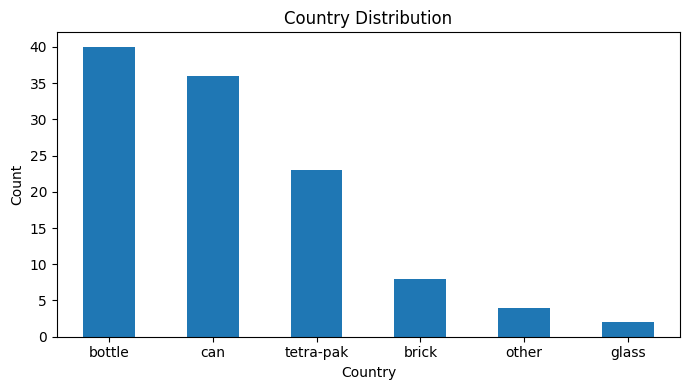

In [142]:
plt.figure(figsize=(7,4))

exploded_packaging.value_counts().head(10).plot(kind='bar')

plt.title("Country Distribution")
plt.ylabel("Count")
plt.xlabel("Country")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

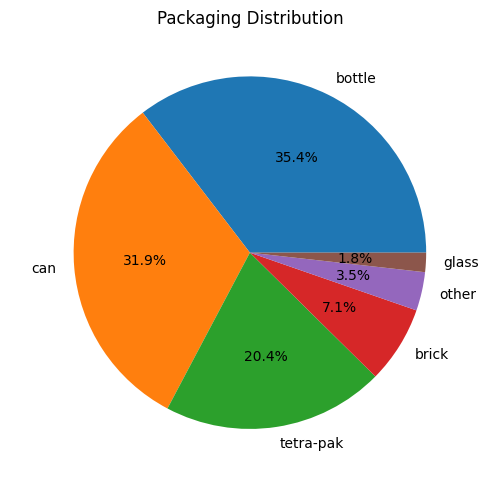

In [158]:
plt.figure(figsize=(5,5))

exploded_packaging.value_counts().plot(kind='pie',autopct='%1.1f%%')

plt.title("Packaging Distribution")
plt.ylabel(" ")

plt.tight_layout()
plt.show()

##  Packaging Distribution – Key Insights

1. **Bottles are the most common packaging type**, representing **35.4%** of the Minute Maid dataset, followed closely by **cans at 31.9%**.

2. **Tetra Pak accounts for 20.4%** of the packaging distribution, making it the third most prevalent packaging type. Together, **bottles, cans, and Tetra Pak represent 87.7%** of the total packaging records.

3. **Brick packaging contributes 7.1%**, while **other packaging types account for 3.5%** and **glass packaging represents only 1.8%** of the dataset.

###  Key Takeaway

The Minute Maid dataset is primarily packaged in **bottles, cans, and Tetra Pak**, which together account for **87.7%** of all packaging records. **Glass and other packaging formats have relatively low representation**, indicating that they have limited impact on the overall packaging distribution.

# Extracting Nutriscore
##  Nutri-Score Grade – Meaning

- **A** → 🟢 **Excellent nutritional quality**
- **B** → 🟢 **Good nutritional quality**
- **C** → 🟡 **Moderate nutritional quality**
- **D** → 🟠 **Lower nutritional quality**
- **E** → 🔴 **Lowest nutritional quality**

In [146]:
df.nutriscore_grade.unique()

array(['c', 'e', 'unknown', 'd', 'b'], dtype=object)

In [147]:
df.nutriscore_grade.value_counts()

nutriscore_grade
unknown    316
e          144
b          102
c           83
d           40
Name: count, dtype: int64

In [148]:
raw_nutriscore = df.nutriscore_grade.value_counts()
raw_nutriscore

nutriscore_grade
unknown    316
e          144
b          102
c           83
d           40
Name: count, dtype: int64

In [149]:
raw_nutriscore = raw_nutriscore.drop("unknown")
raw_nutriscore

nutriscore_grade
e    144
b    102
c     83
d     40
Name: count, dtype: int64

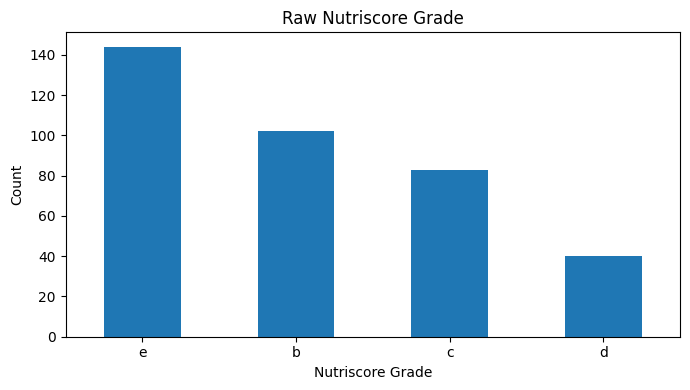

In [175]:
plt.figure(figsize=(7,4))

raw_nutriscore.plot(kind='bar')

plt.title("Raw Nutriscore Grade")
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

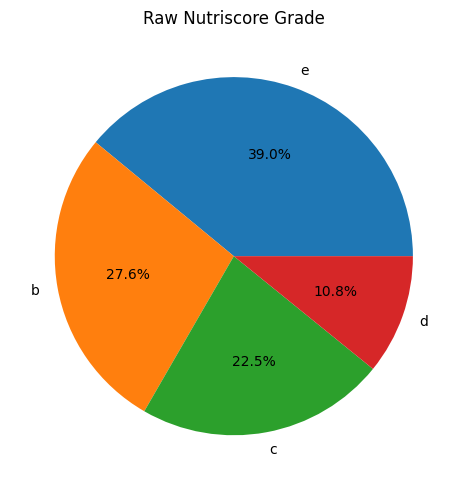

In [161]:
plt.figure(figsize=(5,5))

raw_nutriscore.plot(kind='pie',autopct='%1.1f%%')

plt.title("Raw Nutriscore Grade")
plt.ylabel('')
plt.tight_layout()
plt.show()

##  Nutri-Score Grade Distribution – Key Insights

1. **Grade E is the most common Nutri-Score**, representing **39.0%** of the Minute Maid records. This indicates that a large proportion of the products have a lower nutritional quality according to the Nutri-Score classification.

2. **Grade B accounts for 27.6%** of the records, making it the second-largest category, followed by **Grade C at 22.5%**. Together, Grades B and C represent **50.1%** of the dataset.

3. **Grade D represents 10.8%** of the records, while **Grade A is not present** in the displayed distribution. This suggests that the dataset contains a relatively limited representation of products with the highest Nutri-Score category.

###  Key Takeaway

The Nutri-Score distribution is concentrated mainly in **Grades E, B, and C**, with **E being the largest category at 39.0%**. The absence of Grade A and the relatively high proportion of Grade E indicate that the nutritional quality varies considerably across the Minute Maid products represented in the dataset.

# Extracting Nova Group
##  NOVA Group – Short Meaning

- **Group 1** → 🟢 **Unprocessed or minimally processed foods**
- **Group 2** → 🟡 **Processed culinary ingredients**
- **Group 3** → 🟠 **Processed foods**
- **Group 4** → 🔴 **Ultra-processed foods**

In [170]:
df.nova_group.unique()

array([ 4., nan,  1.,  3.])

In [171]:
df.nova_group.value_counts()
raw_nova = df.nova_group.value_counts()
raw_nova

nova_group
4.0    133
1.0     50
3.0      4
Name: count, dtype: int64

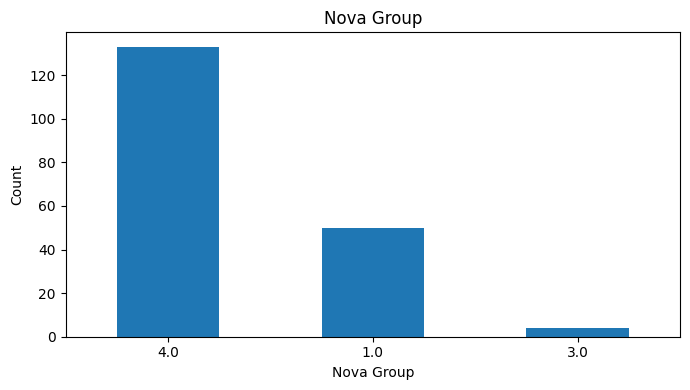

In [174]:
plt.figure(figsize=(7,4))

raw_nova.plot(kind='bar')

plt.title("Nova Group")
plt.xlabel("Nova Group")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

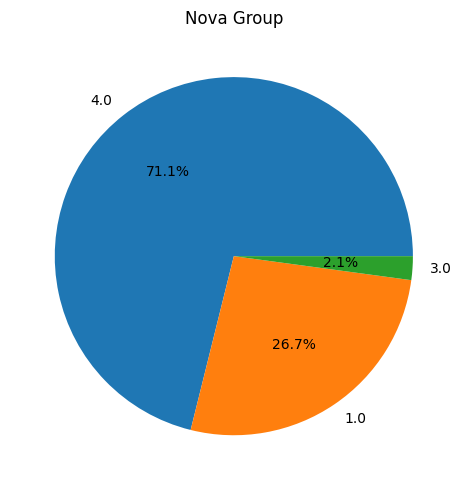

In [176]:
plt.figure(figsize=(5,5))

raw_nova.plot(kind='pie',autopct='%1.1f%%')

plt.title("Nova Group")
plt.ylabel('')
plt.tight_layout()
plt.show()

##  NOVA Group Distribution – Key Insights

1. **NOVA Group 4 dominates the dataset**, accounting for **71.1%** of Minute Maid records. This indicates that the majority of products are classified as **ultra-processed foods**.

2. **NOVA Group 1 represents 26.7%** of the records, showing that a significant portion of the dataset consists of **unprocessed or minimally processed products**.

3. **NOVA Group 3 accounts for only 2.1%** of the records, indicating relatively limited representation of **processed foods** in the dataset. **NOVA Group 2 is not represented** in the displayed distribution.

###  Key Takeaway

The dataset is **heavily concentrated in NOVA Group 4**, with **71.1%** of products classified as ultra-processed. This suggests that processing level is a major characteristic of the Minute Maid products represented in the dataset.

# Country wise observation 

In [35]:
exploded_countries.value_counts()

countries_tags
united-states                          360
france                                 152
canada                                  68
belgium                                 31
world                                   16
philippines                             16
spain                                   13
india                                   13
ireland                                 11
germany                                  8
thailand                                 7
japan                                    7
luxembourg                               5
switzerland                              5
martinique                               4
netherlands                              4
singapore                                4
hong-kong                                3
united-kingdom                           3
malaysia                                 2
china                                    2
kenya                                    2
saint-pierre-and-miquelon              

# FRANCE 


In [36]:
france = df[df['countries_tags'].str.contains("france")]
france

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,0025000034824,"Minute maid, sparkling juice drink, fruit punch",Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,c,4.0,unknown,"Carbonated water, grape and apple juices from ...",NaN,NaN
1,0025000047244,Fruit Cooler Lemonade,Minute Maid,"beverages, carbonated-drinks, sodas, lemonade",france,unknown,unknown,unknown,e,NaN,unknown,unknown,NaN,NaN
4,0025000058073,Lemonade,Minute Maid,"beverages-and-beverages-preparations, beverage...",france,unknown,unknown,unknown,e,4.0,unknown,"Pure filtered water, high fructose corn syrup,...",NaN,NaN
5,0025000061516,100% apple juice,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","france, united-states",unknown,unknown,unknown,e,NaN,unknown,"CONTAINS PURE FILTERED WATER, CONCENTRATED APP...",NaN,NaN
9,0059600060594,Minute Maid Orange,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...",france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654,5449000340023,Jus d'orange Minute Maid,Minute maid,"beverages-and-beverages-preparations, plant-ba...",france,unknown,unknown,unknown,e,NaN,unknown,Jus d'orange à base de concentré (55%) ; eau ;...,NaN,NaN
655,54032491,unknown,Minute Maid,"beverages-and-beverages-preparations, plant-ba...",france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
660,5449000341112,minute maid orange nectar vit c,minute maid,unknown,france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN
666,5449000340108,pack 6x 20cl minute maid orange,minute maid,unknown,france,unknown,unknown,unknown,unknown,NaN,unknown,unknown,NaN,NaN


In [44]:
pfrance = france.copy()

# Packaging of France

In [178]:
pfrance = pfrance[pfrance.packaging_tags != 'unknown']
pfrance.packaging_tags.value_counts()

packaging_tags
can          35
bottle       17
tetra-pak    12
brick         6
glass         2
other         1
Name: count, dtype: int64

In [179]:
pfrance['packaging_tags'] = pfrance['packaging_tags'].str.split(',') 
pfrance = pfrance.explode("packaging_tags")
pfrance['packaging_tags'] = pfrance['packaging_tags'].str.strip() #remove starting void space
pfrance.packaging_tags.value_counts()


packaging_tags
can          35
bottle       17
tetra-pak    12
brick         6
glass         2
other         1
Name: count, dtype: int64

# We can mix Same material, different language or Same concept, different specificity
1. aluminium + recyclable-metals + drink-can + 1-canette-en-metal-a-recycler + conserve + metal = can
2. bouteille-verre + bouteille-consignee + bouteille-en-verre + plastic + plastic-bottle + bottle-or-vial + pet-bottle + th:ขวด + th:ขวดพลาสติก = bottle
3. brique + gold-bricks + box = brick
4. tetra-brik + tetra-brik-aseptic + tetra-pac + cardboard + multilayer-composite + paper-based-carton + card = tetra-pak
5. pasteurized + tumbler + container + orange = other

In [180]:
tag_mapping = {
    # can
    'aluminium': 'can',
    'recyclable-metals': 'can',
    'drink-can': 'can',
    '1-canette-en-metal-a-recycler': 'can',
    'conserve': 'can',
    'metal': 'can',

    # bottle
    'bouteille-verre': 'bottle',
    'bouteille-consignee': 'bottle',
    'bouteille-en-verre': 'bottle',
    'plastic': 'bottle',
    'plastic-bottle': 'bottle',
    'bottle-or-vial': 'bottle',
    'pet-bottle': 'bottle',
    'th:ขวด': 'bottle',
    'th:ขวดพลาสติก': 'bottle',
    

    # brick
    'brique': 'brick',
    'gold-bricks': 'brick',
    'box': 'brick',

    # tetra-pak
    'tetra-brik': 'tetra-pak',
    'tetra-brik-aseptic': 'tetra-pak',
    'tetra-pac': 'tetra-pak',
    'cardboard': 'tetra-pak',
    'multilayer-composite': 'tetra-pak',
    'paper-based-carton': 'tetra-pak',
    'card': 'tetra-pak',
    
    #other
    'pasteurized': 'other',
    'tumbler': 'other',
    'container': 'other',
    'orange': 'other',
    
}

pfrance['packaging_tags'] = pfrance['packaging_tags'].replace(tag_mapping)

pfrance.packaging_tags.value_counts()


packaging_tags
can          35
bottle       17
tetra-pak    12
brick         6
glass         2
other         1
Name: count, dtype: int64

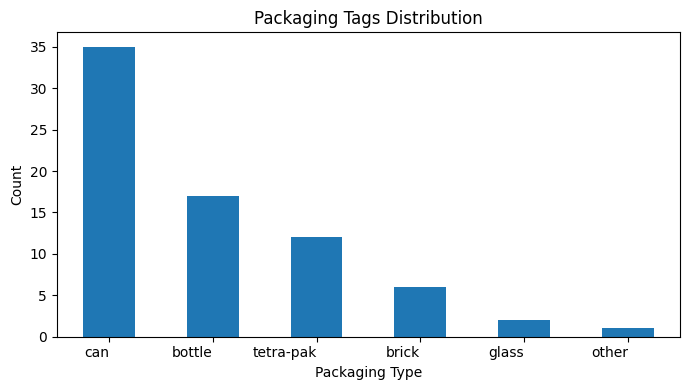

In [184]:
pcounts = pfrance.packaging_tags.value_counts()

plt.figure(figsize=(7, 4))
pcounts.plot(kind='bar')
plt.title('Packaging Tags Distribution')
plt.xlabel('Packaging Type')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

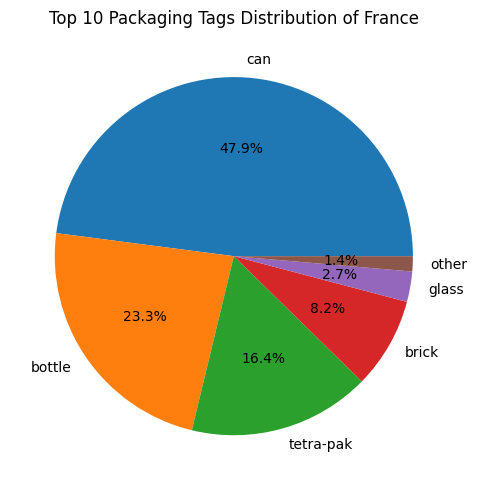

In [183]:
plt.figure(figsize=(5, 5))
pcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Top 10 Packaging Tags Distribution of France')
plt.ylabel('')
plt.tight_layout()
plt.show()

##  Packaging Distribution – France – Key Insights

1. **Cans are the dominant packaging type in France**, accounting for **47.9%** of the records. This indicates that nearly half of the Minute Maid products in the France are packaged in cans.

2. **Bottles represent 23.3%** of the packaging, followed by **Tetra Pak at 16.4%**. Together, cans, bottles, and Tetra Pak account for **87.6%** of the packaging records.

3. **Brick packaging contributes 8.2%**, while **glass (2.7%)** and **other packaging (1.4%)** have relatively small shares.

###  Key Takeaway

The French Minute Maid data is primarily concentrated in **cans, bottles, and Tetra Pak**, with cans being the clear leading packaging format at **47.9%**. Glass and other packaging types have **limited representation** in the dataset.

# Nutriscore Grade of France
##  Nutri-Score Grade – Meaning

- **A** → 🟢 **Excellent nutritional quality**
- **B** → 🟢 **Good nutritional quality**
- **C** → 🟡 **Moderate nutritional quality**
- **D** → 🟠 **Lower nutritional quality**
- **E** → 🔴 **Lowest nutritional quality**

In [185]:
nfrance = france.copy()

In [186]:
nfrance.nutriscore_grade.value_counts()

nutriscore_grade
unknown    61
e          41
c          28
d          18
b           4
Name: count, dtype: int64

In [187]:
nfrance = nfrance[nfrance.nutriscore_grade != 'unknown']
nfrance.nutriscore_grade.value_counts()

nutriscore_grade
e    41
c    28
d    18
b     4
Name: count, dtype: int64

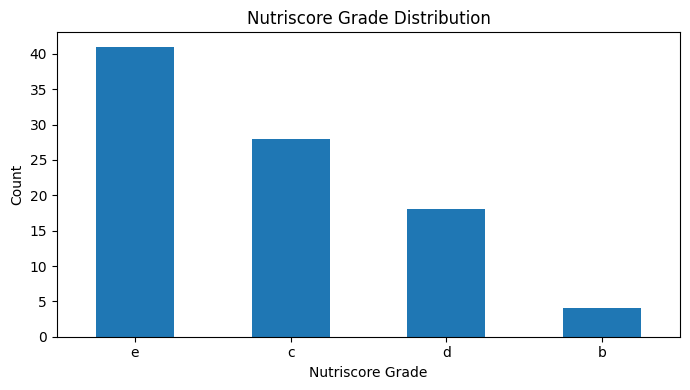

In [190]:
ncounts = nfrance.nutriscore_grade.value_counts()

plt.figure(figsize=(7, 4))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()


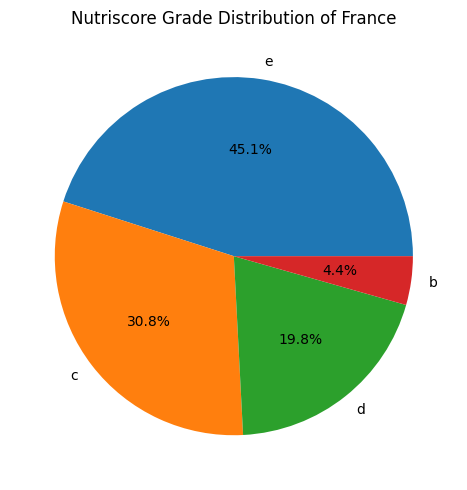

In [189]:
plt.figure(figsize=(5,5))
ncounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nutriscore Grade Distribution of France')
plt.ylabel('')
plt.tight_layout()
plt.show()

##  Nutri-Score Distribution – France – Key Insights

1. **Grade E is the most common Nutri-Score in France**, accounting for **45.1%** of the records. This indicates that nearly half of the products in the France fall into the lowest Nutri-Score category.

2. **Grade C represents 30.8%** of the records, followed by **Grade D at 19.8%**. Together, Grades C and D account for **50.6%** of the French data.

3. **Grade B has the lowest representation at 4.4%**, while **Grade A is not present** in the displayed distribution. This indicates very limited representation of products in the higher Nutri-Score categories.

###  Key Takeaway

The French Minute Maid dataset is largely concentrated in **Grades E, C, and D**, with **95.7%** of records falling into these three categories. The absence of **Grade A** and the dominance of **Grade E (45.1%)** suggest that products in this dataset are predominantly classified toward the lower end of the Nutri-Score scale.

# Nova Group of France 
##  NOVA Group – Short Meaning

- **Group 1** → 🟢 **Unprocessed or minimally processed foods**
- **Group 2** → 🟡 **Processed culinary ingredients**
- **Group 3** → 🟠 **Processed foods**
- **Group 4** → 🔴 **Ultra-processed foods**

In [55]:
nvfrance = france.copy()

In [56]:
nvfrance.nova_group.value_counts()

nova_group
4.0    36
1.0    27
3.0     2
Name: count, dtype: int64

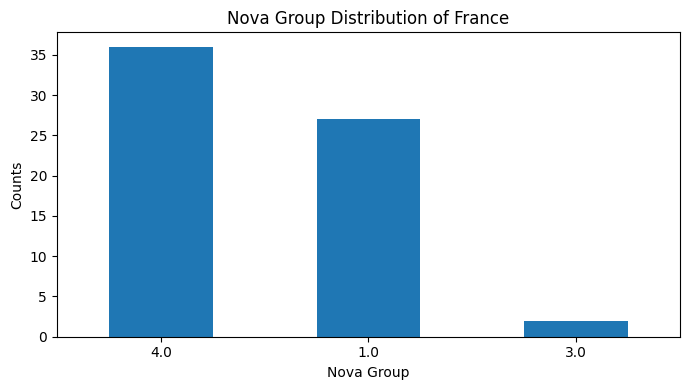

In [192]:
nvcounts = nvfrance.nova_group.value_counts()

plt.figure(figsize=(7,4))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of France')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

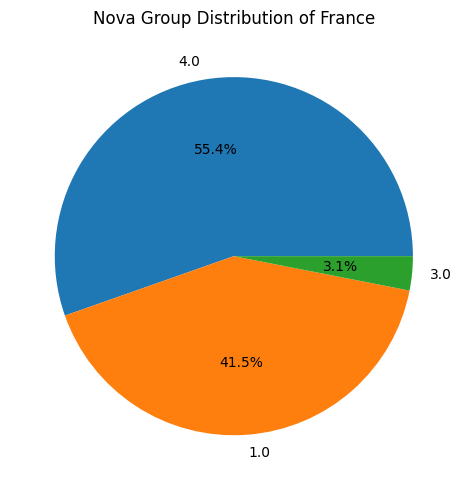

In [193]:
plt.figure(figsize=(5, 5))
nvcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nova Group Distribution of France')
plt.ylabel('')
plt.tight_layout()
plt.show()

##  NOVA Group Distribution – France – Key Insights

1. **NOVA Group 4 dominates the France**, accounting for **55.4%** of the records. This indicates that more than half of the products are classified as **ultra-processed**.

2. **NOVA Group 1 represents 41.5%** of the records, showing that a substantial portion of the products are classified as **unprocessed or minimally processed**.

3. **NOVA Group 3 accounts for only 3.1%** of the records, indicating very limited representation of **processed foods**. **NOVA Group 2 is not represented** in the French dataset.

###  Key Takeaway

The French Minute Maid dataset is mainly divided between **NOVA Group 4 (55.4%) and Group 1 (41.5%)**, which together account for **96.9%** of the records. This shows a strong concentration at the two extremes of the NOVA processing classification, with very limited representation of Group 3.

##  Data Processing Limitation

The columns **`nutriments.sugars_100g`**, **`nutriments.energy-kcal_100g`**, and **`ecoscore_grade`** contain a high proportion of **Null or Unknown values**.

Due to the limited availability of reliable data in these fields, further processing and analysis could not be performed effectively. Using these columns with substantial missing data could lead to **inaccurate or unreliable insights**.

###  Key Takeaway

These variables were excluded from further analysis because their **high percentage of missing or unknown values limits their reliability and analytical usefulness**.

# BELGIUM

In [194]:
belgium = df[df['countries_tags'].str.contains('belgium')]
belgium

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
29,42104773,Minute Maid Multivitamines,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","belgium, france, luxembourg","tetra-pak, tetra-brik-aseptic",Delhaize,unknown,e,4.0,unknown,eau; jus de fruits à base de concentré: orange...,NaN,NaN
32,54008304,Minute Maid Orange,Minute Maid,"beverages-and-beverages-preparations, plant-ba...","belgium, france",unknown,unknown,unknown,c,1.0,unknown,Jus d'orange 100%,NaN,NaN
33,5449000002860,Orange original minute maid,unknown,groceries,belgium,unknown,unknown,unknown,c,1.0,unknown,Orange concentré eau,NaN,NaN
35,5449000034274,Jus d'orange avec pulpe à base de concentré doux,Minute maid,"beverages-and-beverages-preparations, plant-ba...","belgium, france",tetra-brik,unknown,unknown,d,1.0,unknown,Jus d'orange avec pulpe à base de concentré,NaN,NaN
36,5449000045614,Minute Maid tropical,Minute Maid,"beverages-and-beverages-preparations, plant-ba...","belgium, france, martinique, switzerland","metal, can, drink-can",unknown,unknown,e,4.0,unknown,Eau ; jus de fruits à base de concentré (orang...,NaN,NaN
40,5449000098870,Minute Maid multivitamines,"Coca-Cola, Minute Maid","plant-based-foods-and-beverages, beverages, pl...","belgium, france","brick, cardboard",unknown,Belgium,e,4.0,unknown,"Eau, jus de fruits à base de concentré : orang...",NaN,NaN
41,5449000100573,Minute Maid multivitamines,Minute Maid,"beverages-and-beverages-preparations, plant-ba...","belgium, france",can,unknown,Belgium,e,4.0,unknown,eau; jus de fruits à base de concentré: orange...,NaN,NaN
42,5449000101068,Minute Maid Multivitamins Brik 20CL 4-pack,Minute Maid,unknown,"belgium, france, world",unknown,Delhaize,unknown,unknown,NaN,unknown,unknown,NaN,NaN
44,5449000111104,Great Start!,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","belgium, france","brick, cardboard",Noz,"Courrières,France",d,4.0,unknown,"Jus de fruits à base de concentré (orange 53%,...",NaN,NaN
67,5449000243416,Minute Maid Orange,Minute Maid,"plant-based-foods-and-beverages, beverages, pl...","belgium, france",brick,colruyt,unknown,c,1.0,unknown,JUS D'ORANGE À BASE DE CONCENTRé,NaN,NaN


In [195]:
pbelgium = belgium.copy()

# Packaging in Belgium


In [196]:
pbelgium.packaging_tags.value_counts()


packaging_tags
unknown                          16
tetra-brik                        2
plastic, bottle                   2
brick, cardboard                  2
can, drink-can                    2
tetra-pak, tetra-brik-aseptic     1
metal, can, drink-can             1
can                               1
brique                            1
brick                             1
bottle                            1
tetra-pak, brick, gold-bricks     1
Name: count, dtype: int64

In [197]:
pbelgium = pbelgium[pbelgium.packaging_tags != 'unknown']
pbelgium.packaging_tags.value_counts()

packaging_tags
tetra-brik                       2
plastic, bottle                  2
brick, cardboard                 2
can, drink-can                   2
tetra-pak, tetra-brik-aseptic    1
metal, can, drink-can            1
can                              1
brique                           1
brick                            1
bottle                           1
tetra-pak, brick, gold-bricks    1
Name: count, dtype: int64

In [198]:
pbelgium['packaging_tags'] = pbelgium['packaging_tags'].str.split(',')
pbelgium = pbelgium.explode('packaging_tags')
pbelgium['packaging_tags'] = pbelgium['packaging_tags'].str.strip()
pbelgium.packaging_tags.value_counts()

packaging_tags
brick                 4
can                   4
bottle                3
drink-can             3
cardboard             2
plastic               2
tetra-brik            2
tetra-pak             2
metal                 1
tetra-brik-aseptic    1
brique                1
gold-bricks           1
Name: count, dtype: int64

In [199]:
tag_mapping = {
    # can
    'aluminium': 'can',
    'recyclable-metals': 'can',
    'drink-can': 'can',
    '1-canette-en-metal-a-recycler': 'can',
    'conserve': 'can',
    'metal': 'can',

    # bottle
    'bouteille-verre': 'bottle',
    'bouteille-consignee': 'bottle',
    'bouteille-en-verre': 'bottle',
    'plastic': 'bottle',
    'plastic-bottle': 'bottle',
    'bottle-or-vial': 'bottle',
    'pet-bottle': 'bottle',
    'th:ขวด': 'bottle',
    'th:ขวดพลาสติก': 'bottle',
    

    # brick
    'brique': 'brick',
    'gold-bricks': 'brick',
    'box': 'brick',

    # tetra-pak
    'tetra-brik': 'tetra-pak',
    'tetra-brik-aseptic': 'tetra-pak',
    'tetra-pac': 'tetra-pak',
    'cardboard': 'tetra-pak',
    'multilayer-composite': 'tetra-pak',
    'paper-based-carton': 'tetra-pak',
    'card': 'tetra-pak',
    
    #other
    'pasteurized': 'other',
    'tumbler': 'other',
    'container': 'other',
    'orange': 'other',
}

pbelgium['packaging_tags'] = pbelgium['packaging_tags'].replace(tag_mapping)

pbelgium.packaging_tags.value_counts()

packaging_tags
can          8
tetra-pak    7
brick        6
bottle       5
Name: count, dtype: int64

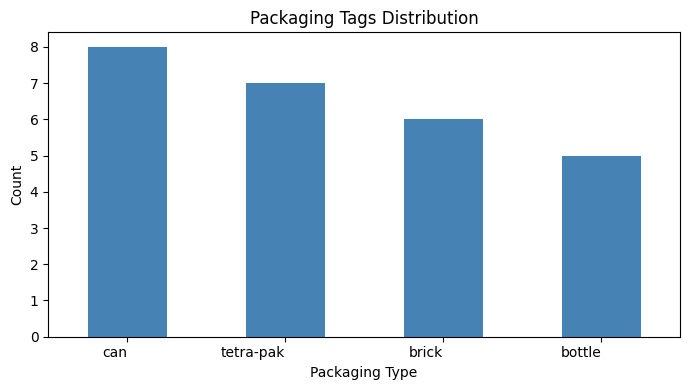

In [203]:
pcounts = pbelgium.packaging_tags.value_counts()

plt.figure(figsize=(7, 4))
pcounts.plot(kind='bar', color='steelblue')
plt.title('Packaging Tags Distribution')
plt.xlabel('Packaging Type')
plt.ylabel('Count')
plt.xticks(rotation=0, ha='right')
plt.tight_layout()
plt.show()

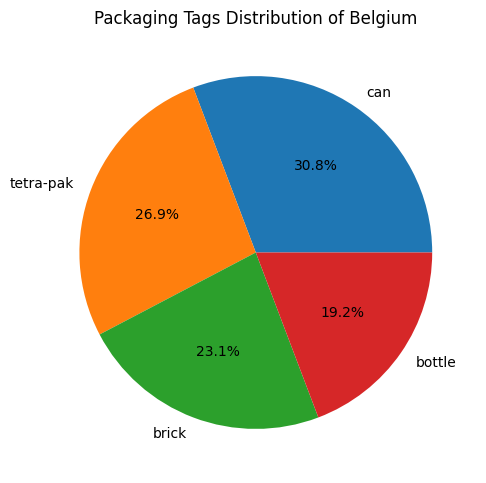

In [213]:
plt.figure(figsize=(5,5))
pcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Packaging Tags Distribution of Belgium')
plt.ylabel('')
plt.tight_layout()
plt.show()

##  Packaging Distribution – Belgium – Key Insights

1. **Cans are the most common packaging type in Belgium**, accounting for **30.8%** of the records. This makes cans the leading packaging format in the Belgium.

2. **Tetra Pak represents 26.9%** of the packaging, followed by **brick at 23.1%** and **bottle at 19.2%**. The relatively close distribution indicates that Belgium uses a more diversified range of packaging formats compared with France.

3. **Can, Tetra Pak, and brick packaging together account for 80.8%** of the records, showing that these three formats dominate the Belgian packaging distribution.

###  Key Takeaway

The Belgian Minute Maid dataset shows a **more balanced packaging distribution**, with cans leading at **30.8%**, followed by Tetra Pak (**26.9%**) and brick (**23.1%**). Unlike France, where cans strongly dominate, Belgium has a comparatively **diverse packaging mix**.

In [214]:
nbelgium = belgium.copy()

# Belgium Nutriscore 
##  Nutri-Score Grade – Meaning

- **A** → 🟢 **Excellent nutritional quality**
- **B** → 🟢 **Good nutritional quality**
- **C** → 🟡 **Moderate nutritional quality**
- **D** → 🟠 **Lower nutritional quality**
- **E** → 🔴 **Lowest nutritional quality**

In [215]:
nbelgium.nutriscore_grade.value_counts()

nutriscore_grade
c          14
e           8
unknown     5
d           4
Name: count, dtype: int64

In [216]:
nbelgium = nbelgium[nbelgium['nutriscore_grade'] != 'unknown']
nbelgium.nutriscore_grade.value_counts()

nutriscore_grade
c    14
e     8
d     4
Name: count, dtype: int64

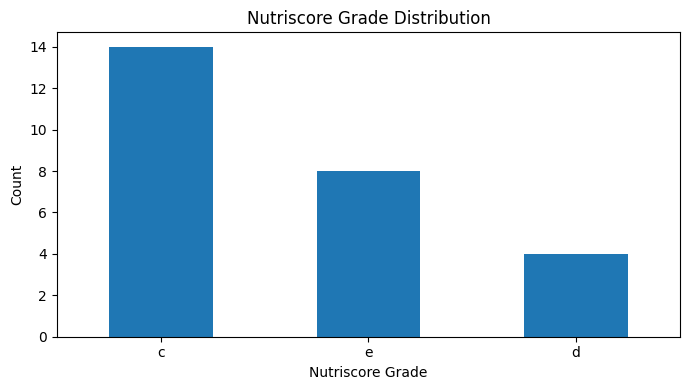

In [217]:
ncounts = nbelgium.nutriscore_grade.value_counts()

plt.figure(figsize=(7, 4))
ncounts.plot(kind='bar')
plt.title('Nutriscore Grade Distribution')
plt.xlabel('Nutriscore Grade')
plt.ylabel('Count')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

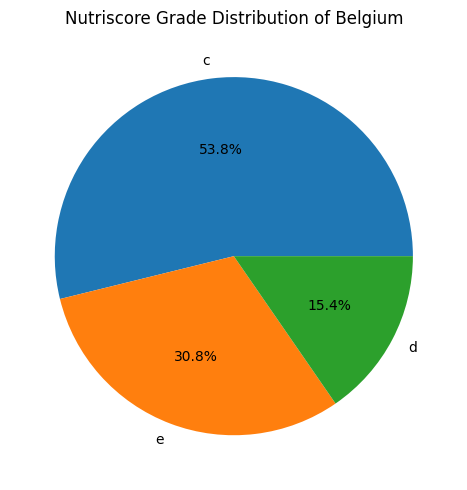

In [218]:
plt.figure(figsize=(5,5))
ncounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nutriscore Grade Distribution of Belgium')
plt.ylabel('')
plt.tight_layout()
plt.show()

##  Nutri-Score Distribution – Belgium – Key Insights

1. **Grade C is the most common Nutri-Score in Belgium**, accounting for **53.8%** of the records. This indicates that more than half of the products fall into the moderate nutritional quality category.

2. **Grade E represents 30.8%** of the records, followed by **Grade D at 15.4%**. Together, Grades D and E account for **46.2%** in the Belgium

3. **No products are represented in Grades A or B** in the displayed distribution, indicating that higher Nutri-Score categories have very limited or no representation in this Belgian dataset.

###  Key Takeaway

The Belgian Minute Maid dataset is concentrated in **Grades C, D, and E**, with **C being dominant at 53.8%**. The absence of Grades A and B suggests that the products represented in this dataset are predominantly classified in the **moderate-to-lower Nutri-Score categories**.

In [72]:
nvbelgium = belgium.copy()

# Belgium Nova Group
##  NOVA Group – Short Meaning

- **Group 1** → 🟢 **Unprocessed or minimally processed foods**
- **Group 2** → 🟡 **Processed culinary ingredients**
- **Group 3** → 🟠 **Processed foods**
- **Group 4** → 🔴 **Ultra-processed foods**

In [208]:
nvbelgium.nova_group.value_counts()

nova_group
4.0    8
1.0    8
Name: count, dtype: int64

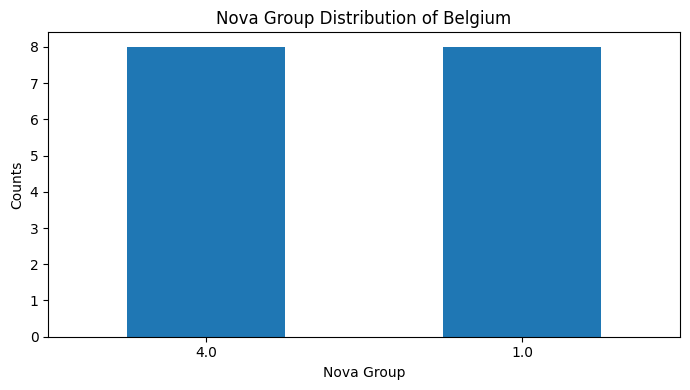

In [210]:
nvcounts = nvbelgium.nova_group.value_counts()

plt.figure(figsize=(7,4))
nvcounts.plot(kind='bar')
plt.title('Nova Group Distribution of Belgium')
plt.xlabel('Nova Group')
plt.ylabel('Counts')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

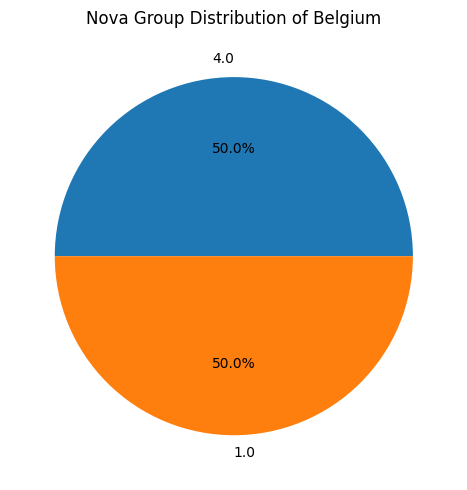

In [211]:
plt.figure(figsize=(5,5))
nvcounts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Nova Group Distribution of Belgium')
plt.ylabel('')
plt.tight_layout()
plt.show()

##  NOVA Group Distribution – Belgium – Key Insights

1. **NOVA Group 4 accounts for 50.0%** of the Belgian dataset, indicating that half of the products are classified as **ultra-processed foods**.

2. **NOVA Group 1 also accounts for 50.0%**, showing that the remaining half of the products are classified as **unprocessed or minimally processed foods**.

3. **NOVA Groups 2 and 3 are not represented** in the displayed Belgian dataset, indicating no records for processed culinary ingredients or processed foods.

###  Key Takeaway

The Belgian Minute Maid dataset shows an **even 50–50 distribution between NOVA Group 1 and Group 4**, with no representation from Groups 2 and 3. This indicates that the available Belgian records are concentrated at the **two extremes of the food-processing classification**.

##  Data Processing Limitation

The columns **`nutriments.sugars_100g`**, **`nutriments.energy-kcal_100g`**, and **`ecoscore_grade`** contain a high proportion of **Null or Unknown values**.

Due to the limited availability of reliable data in these fields, further processing and analysis could not be performed effectively. Using these columns with substantial missing data could lead to **inaccurate or unreliable insights**.

###  Key Takeaway

These variables were excluded from further analysis because their **high percentage of missing or unknown values limits their reliability and analytical usefulness**.

## ⚠️ Data Availability Limitation

- **United States and Canada:** The available data was processed by our teammates due to comparatively sufficient data coverage.

- **Other countries:** Further processing and analysis could not be performed because of **limited data availability and a high proportion of missing or unknown values**.

- Approximately **95% of the records for the remaining countries contain `Unknown` or `Null` values** in key fields, making it difficult to derive reliable and meaningful insights.

###  Key Takeaway

Due to the **high level of missing/unknown data and insufficient sample sizes**, the remaining countries were excluded from further analysis to avoid drawing **unreliable or statistically insignificant conclusions**.
